# Imports && Constants


In [32]:
from distutils.command.clean import clean

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import os

In [33]:
# --- Color Constants ---
GREEN = '\033[92m'
YELLOW = '\033[93m'
RED = '\033[91m'
RESET_COLORS = '\033[0m'

# --- Paths Configuration ---
# Based on your sidebar: data -> dataset -> dataset -> Dropbox_Dataset.npy
RAW_DATA_NPY = '../data/Dropbox_Dataset.npy'
CLEAN_DATA_NPY = '../data/dataset_clean.npy'
PLOTS_DIR = '../plots/'

# --- Project Constants ---
MIN_RATINGS_THRESHOLD = 3
TRUSTED_USERS_PLOT = os.path.join(PLOTS_DIR, 'trusted_users_dispersion.png')

# --- Safety Check & Directory Setup ---
# 1. Fix the IsADirectoryError (Delete the folder if it exists)
if os.path.isdir(CLEAN_DATA_NPY):
    shutil.rmtree(CLEAN_DATA_NPY)
    print(f"{YELLOW}Cleaned up accidental directory: {CLEAN_DATA_NPY}{RESET_COLORS}")

# 2. Ensure the plots directory exists
if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)
    print(f"{GREEN}Directory 'plots' is ready.{RESET_COLORS}")

# 3. Ensure the data directory exists (where CLEAN_DATA_NPY will live)
output_folder = os.path.dirname(CLEAN_DATA_NPY)
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"{GREEN}Output directory '{output_folder}' is ready.{RESET_COLORS}")

## Create and save DF

In [34]:
raw_data = np.load(RAW_DATA_NPY, allow_pickle=True)
data_pd = pd.Series(raw_data)

# 2. Split into columns
split_data = data_pd.str.split(',', expand=True)

# 3. Validation Check
if len(split_data.columns) > 4:
    print(f"{YELLOW}Warning: Extra columns detected. Check for commas in usernames.{RESET_COLORS}")
else:
    print(f"{GREEN}Structure verified: 4 columns found.{RESET_COLORS}")

# 4. Cleaning and Type Casting
# split_data[0]: UserID (urXXXX) -> int
# split_data[1]: MovieID (ttXXXX) -> int
# split_data[2]: RATING -> int
# split_data[3]: Date -> datetime
split_data[0] = split_data[0].str[2:].astype(int)
split_data[1] = split_data[1].str[2:].astype(int)
split_data[2] = split_data[2].astype(int)
split_data[3] = pd.to_datetime(split_data[3])

# 5. RATING Validation
invalid_RATINGs = split_data[(split_data[2] < 0) | (split_data[2] > 10)]
if not invalid_RATINGs.empty:
    print(f"{RED}Error: Found {len(invalid_RATINGs)} invalid RATINGs.{RESET_COLORS}")
else:
    print(f"{GREEN}Success: All RATINGs are within the 0-10 range.{RESET_COLORS}")

# 6. Final Save
np.save(CLEAN_DATA_NPY, split_data.to_numpy())
print(f"{GREEN}Data successfully saved to: {CLEAN_DATA_NPY}{RESET_COLORS}")

Structure verified: 4 columns found.
Success: All RATINGs are within the 0-10 range.
Data successfully saved to: ../data/dataset_clean.npy


## Rename columns

In [35]:
print(split_data.head(5))
print(split_data.columns)

split_data.columns = ['USER_ID', 'MOVIE_ID', 'RATING', 'TIMESTAMP']

# --- Print the column names ---
print(f"{GREEN}Current Column Names:{RESET_COLORS}")
print(split_data.columns.tolist())

# --- Display the first few rows to see the data with the new headers ---
print(f"\n{GREEN}Data Preview:{RESET_COLORS}")
print(split_data.head())

         0       1   2          3
0  4592644  120884  10 2005-01-16
1  3174947  118688   3 2005-01-16
2  3780035  387887   8 2005-01-16
3  4592628  346491   1 2005-01-16
4  3174947   94721   8 2005-01-16
RangeIndex(start=0, stop=4, step=1)
Current Column Names:
['USER_ID', 'MOVIE_ID', 'RATING', 'TIMESTAMP']

Data Preview:
   USER_ID  MOVIE_ID  RATING  TIMESTAMP
0  4592644    120884      10 2005-01-16
1  3174947    118688       3 2005-01-16
2  3780035    387887       8 2005-01-16
3  4592628    346491       1 2005-01-16
4  3174947     94721       8 2005-01-16


# Feature Engineering

## Pre - clustering

### Dimensionality Analysis

In [36]:
n_users = split_data['USER_ID'].nunique()
n_movies = split_data['MOVIE_ID'].nunique()
n_ratings = len(split_data)

possible_RATINGs = n_users * n_movies
sparsity = 1 - (n_ratings / possible_RATINGs)

print(f"Users: {n_users} | Movies: {n_movies}")
print(f"Sparsity: {sparsity * 100:.2f}%")

Users: 1499238 | Movies: 351109
Sparsity: 100.00%


### Label enconding

In [37]:
user_enc = LabelEncoder()
movie_enc = LabelEncoder()

split_data['USER_IDx'] = user_enc.fit_transform(split_data['USER_ID'])
split_data['MOVIE_IDx'] = movie_enc.fit_transform(split_data['MOVIE_ID'])

### Creating the "User Vectors" for Clustering

In [38]:
# Create a Compressed Sparse Row matrix
# row = user index, col = movie index, data = RATING
user_movie_matrix = csr_matrix((split_data['RATING'], (split_data['USER_IDx'], split_data['MOVIE_IDx'])))

## Movies ratings analysis

### 1-2 ratings %

--- Dataset Audit ---
Total Unique Users: 1499238
Trusted Users (3+): 237771 (15.86%)
Low-Rated Movies:   91491
Of which are Niche: 19695
-----------------------------------


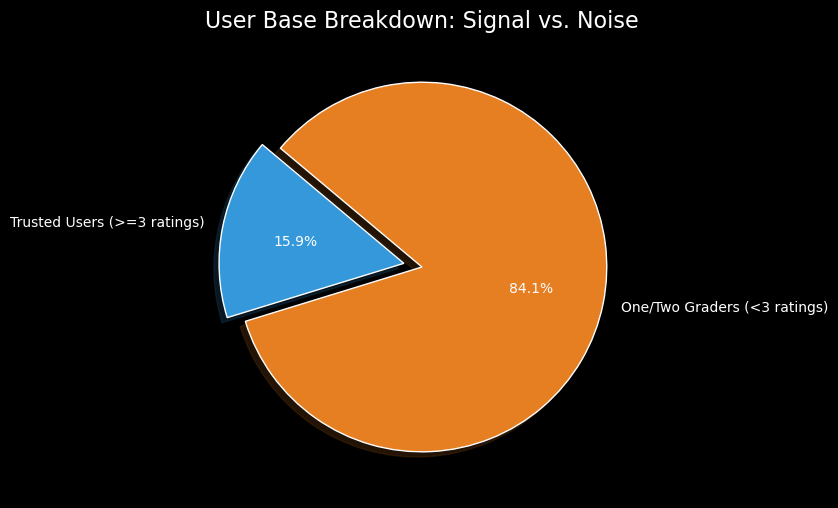

Success: 'one_or_two_graders' created and Pie Plot saved.


In [39]:
# --- 1. Identify "Trusted" vs "One-Timer" Users ---
user_counts = split_data['USER_ID'].value_counts()
trusted_mask = user_counts >= 3
trusted_user_ids = user_counts[trusted_mask].index
low_activity_user_ids = user_counts[~trusted_mask].index

# Create the separate DF for low-activity users as requested
one_or_two_graders = split_data[split_data['USER_ID'].isin(low_activity_user_ids)].copy()

# --- 2. Calculate User Percentages for Pie ---
total_users = split_data['USER_ID'].nunique()
trusted_count = len(trusted_user_ids)
low_act_count = len(low_activity_user_ids)

# --- 3. Identify Niche vs Low-Rated Movies ---
# Niche = Movies with only 1-2 ratings total
movie_counts = split_data['MOVIE_ID'].value_counts()
niche_movie_ids = movie_counts[movie_counts <= 2].index

# Low Rated = Movies with a score of 1 or 2
low_rating_mask = (split_data['RATING'] >= 1) & (split_data['RATING'] <= 2)
low_rated_movie_ids = split_data.loc[low_rating_mask, 'MOVIE_ID'].unique()

# --- 4. Cross-Reference (The fix for your NameError) ---
bad_niche_movies = set(low_rated_movie_ids).intersection(set(niche_movie_ids))

# --- 5. Print Statistics ---
print(f"{YELLOW}--- Dataset Audit ---{RESET_COLORS}")
print(f"Total Unique Users: {total_users}")
print(f"Trusted Users (3+): {trusted_count} ({(trusted_count/total_users)*100:.2f}%)")
print(f"Low-Rated Movies:   {len(low_rated_movie_ids)}")
print(f"Of which are Niche: {len(bad_niche_movies)}")
print("-" * 35)

# --- 6. Create User Activity Pie Plot ---
labels = [f'Trusted Users (>=3 ratings)', f'One/Two Graders (<3 ratings)']
sizes = [trusted_count, low_act_count]
colors = ['#3498db', '#e67e22']
explode = (0.1, 0)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('User Base Breakdown: Signal vs. Noise')

# Save the plot
plt.savefig(os.path.join(PLOTS_DIR, 'user_activity_pie.png'))
plt.show()

print(f"{GREEN}Success: 'one_or_two_graders' created and Pie Plot saved.{RESET_COLORS}")

### 9-10 ratings %

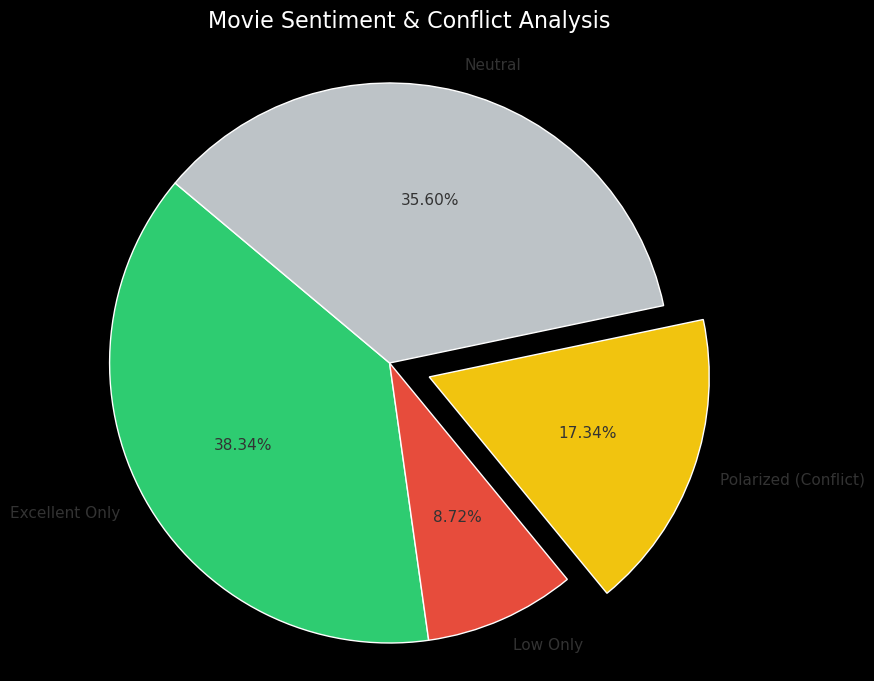

--- Numerical Sentiment Breakdown ---
Total Unique Movies: 351109
Excellent Only:      134620
Low Only:            30601
Polarized:           60890
Neutral:             124998


In [63]:
# --- 1. Identify Excellent Ratings (Value 9 or 10) ---
# We look for rows where the actual score is 9 or 10
high_rating_mask = split_data['RATING'] >= 9
excellent_reviews_df = split_data[high_rating_mask].copy()

# --- 2. Identify "Excellent Movies" ---
# These are unique movies that have received at least one 9 or 10
excellent_movie_ids = excellent_reviews_df['MOVIE_ID'].unique()

# --- 3. Calculate Percentages ---
total_unique_movies = split_data['MOVIE_ID'].nunique()
excellent_movie_count = len(excellent_movie_ids)
percentage_excellent = (excellent_movie_count / total_unique_movies) * 100

# --- 4. Print Results ---
print(f"{YELLOW}--- High-Quality Movie Statistics ---{RESET_COLORS}")
print(f"Total unique movies in dataset:      {total_unique_movies}")
print(f"Unique movies with 9-10 ratings:     {excellent_movie_count}")
print(f"{GREEN}Percentage of 'Excellent' movies:    {percentage_excellent:.2f}%{RESET_COLORS}")
print("-" * 35)


# --- 6. Preview ---
print(f"\n{RED}Sample of Excellent Ratings:{RESET_COLORS}")
print(excellent_reviews_df[['MOVIE_ID', 'RATING']].head())

### **Polarizing Movies** (movies with both 1-2 or 9-10 ratings)

In [62]:
# --- 1. Identify Movies with Low Ratings (Value 1-2) ---
# Unique IDs of movies that have received at least one rating of 1 or 2
low_val_mask = (split_data['RATING'] >= 1) & (split_data['RATING'] <= 2)
movies_with_low_vals = set(split_data.loc[low_val_mask, 'MOVIE_ID'].unique())

# --- 2. Identify Movies with High Ratings (Value 9-10) ---
# Unique IDs of movies that have received at least one rating of 9 or 10
high_val_mask = (split_data['RATING'] >= 9) & (split_data['RATING'] <= 10)
movies_with_high_vals = set(split_data.loc[high_val_mask, 'MOVIE_ID'].unique())

# --- 3. Identify Polarizing Movies (Intersection) ---
# These are movies that appear in BOTH lists
polarizing_movie_ids = movies_with_low_vals.intersection(movies_with_high_vals)

# --- 4. Calculate Percentages ---
total_unique_movies = split_data['MOVIE_ID'].nunique()
polarizing_count = len(polarizing_movie_ids)
percentage_polarizing = (polarizing_count / total_unique_movies) * 100

# --- 5. Print Results ---
print(f"{YELLOW}--- Polarizing Movies Analysis (Love/Hate) ---{RESET_COLORS}")
print(f"Total unique movies in library:      {total_unique_movies}")
print(f"Movies with 'Haters' (1-2 ratings):  {len(movies_with_low_vals)}")
print(f"Movies with 'Fans' (9-10 ratings):    {len(movies_with_high_vals)}")
print("-" * 45)
print(f"Polarizing Movies (have BOTH 1-2 and 9-10): {polarizing_count}")
print(f"{RED}Percentage of Polarizing Movies:      {percentage_polarizing:.2f}%{RESET_COLORS}")
print("-" * 45)

# --- 6. Preview ---
if polarizing_count > 0:
    print(f"{GREEN}Sample of Polarizing Movie IDs:{RESET_COLORS}")
    print(list(polarizing_movie_ids)[:5])

--- Polarizing Movies Analysis (Love/Hate) ---
Total unique movies in library:      351109
Movies with 'Haters' (1-2 ratings):  91491
Movies with 'Fans' (9-10 ratings):    195510
---------------------------------------------
Polarizing Movies (have BOTH 1-2 and 9-10): 60890
Percentage of Polarizing Movies:      17.34%
---------------------------------------------
Sample of Polarizing Movie IDs:
[np.int64(1), np.int64(5), np.int64(262150), np.int64(2621446), np.int64(8)]


### Plot pure-low-grade vs pure-excellent-grade vs polarized-grade vs neutral-grade %
- pure-low: low_unique_count - polarizing_count
- pure-excellent: excellent_movie_count - polarizing_count
-  total_unique_movies - (pure_excellent + pure_low + polarized)


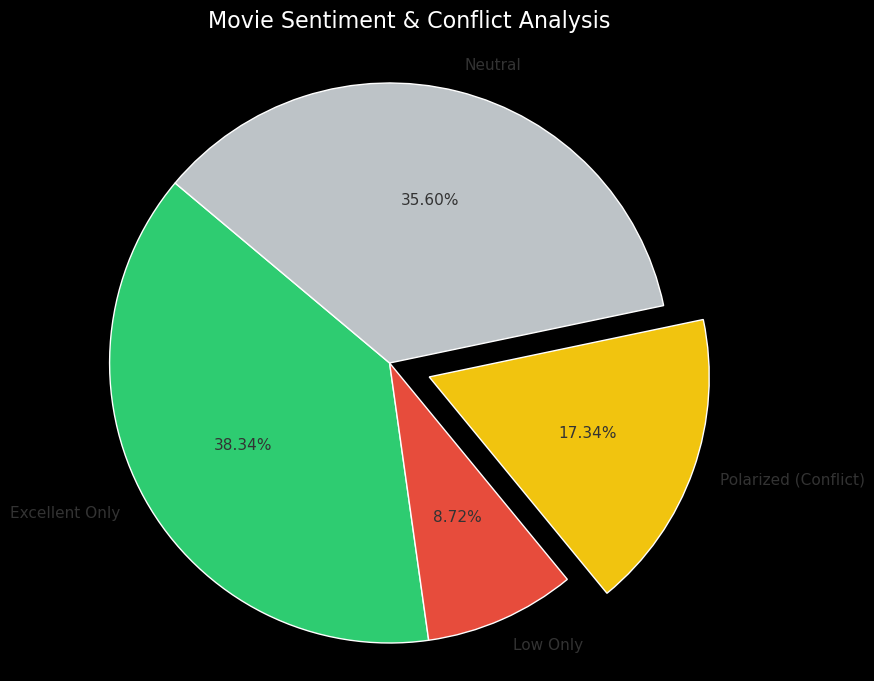

--- Numerical Sentiment Breakdown ---
Total Unique Movies: 351109
Excellent Only:      134620
Low Only:            30601
Polarized:           60890
Neutral:             124998


In [64]:
try:
    # 1. Use the correct DataFrame and column names from your notebook
    # In your notebook, the main table is 'split_data'
    working_df = split_data

    # Match the exact column names seen in Cell 3/33
    col_movie = 'MOVIE_ID'
    col_rating = 'RATING'

    # Ensure RATING is numeric (Just in case it was still strings)
    working_df[col_rating] = pd.to_numeric(working_df[col_rating], errors='coerce')

    # 2. Group by movie and get unique ratings
    movie_ratings_sets = working_df.groupby(col_movie)[col_rating].unique()
    total_unique_movies = len(movie_ratings_sets)

    # 3. Categorization Logic
    # Excellent: Has 9 or 10 | Low: Has 1 or 2
    excellent_mask = movie_ratings_sets.apply(lambda x: any(r >= 9 for r in x))
    low_mask = movie_ratings_sets.apply(lambda x: any(r <= 2 for r in x))

    # Calculate counts
    excellent_movie_count = excellent_mask.sum()
    low_unique_count = low_mask.sum()
    polarizing_count = (excellent_mask & low_mask).sum()

    # 4. Exclusive Slices for Pie Chart
    pure_excellent = excellent_movie_count - polarizing_count
    pure_low = low_unique_count - polarizing_count
    polarized = polarizing_count
    neutral_movies = total_unique_movies - (pure_excellent + pure_low + polarized)

    # 5. Plotting (Using your White Theme)
    plt.figure(figsize=(10, 8))
    labels = ['Excellent Only', 'Low Only', 'Polarized (Conflict)', 'Neutral']
    sizes = [pure_excellent, pure_low, polarized, neutral_movies]
    colors = ['#2ecc71', '#e74c3c', '#f1c40f', '#bdc3c7'] # Green, Red, Gold, Silver
    explode = (0, 0, 0.15, 0) # Highlight the Polarized slice

    # autopct='%1.2f%%' ensures 2 decimal precision in the plot
    plt.pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct='%1.2f%%', shadow=False, startangle=140,
            textprops={'fontsize': 11, 'color': '#333333'})

    plt.title('Movie Sentiment & Conflict Analysis', fontsize=16, pad=20)
    plt.axis('equal')
    plt.show()

    # 6. Print Stats with Colors and 2 Decimal Precision
    print(f"{YELLOW}--- Numerical Sentiment Breakdown ---{RESET_COLORS}")
    print(f"Total Unique Movies: {total_unique_movies}")
    print(f"Excellent Only:      {GREEN}{pure_excellent}{RESET_COLORS}")
    print(f"Low Only:            {RED}{pure_low}{RESET_COLORS}")
    print(f"Polarized:           {YELLOW}{polarized}{RESET_COLORS}")
    print(f"Neutral:             {neutral_movies}")

except Exception as e:
    print(f"{RED}Error rebuilding sentiment analysis: {e}{RESET_COLORS}")

### Plot % of users with at least 3 rated movies


--- User Statistics ---
Total Unique Users:  1499238
Trusted Users:       237771 (15.86%)
Low Activity Users:  1261467 (84.14%)
-----------------------------------
Pie chart saved to: ../plots/user_activity_pie.png


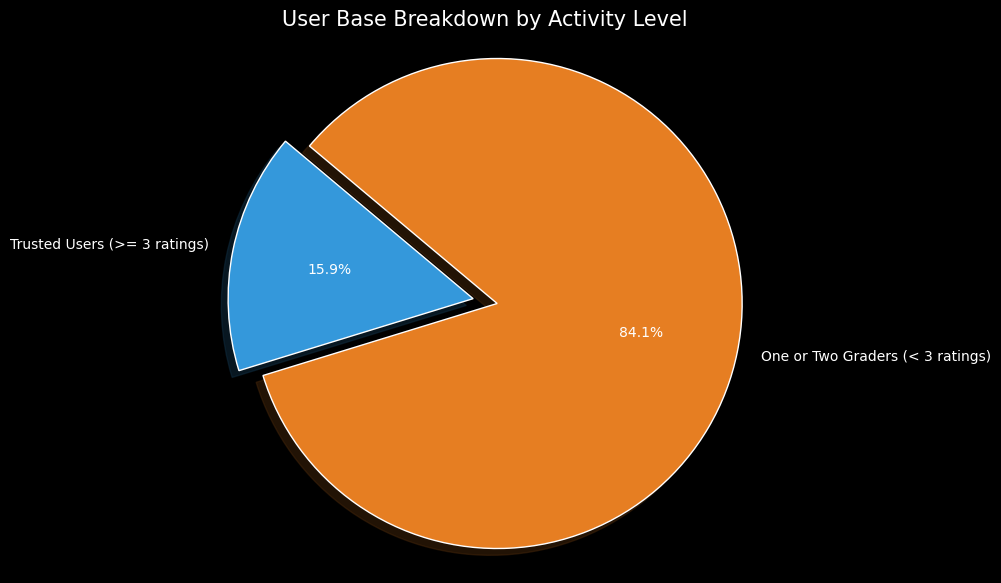

In [43]:
import matplotlib.pyplot as plt

# --- 1. Calculate User Activity Counts ---
# Total unique users in the dataset
total_unique_users = split_data['USER_ID'].nunique()

# user_counts was defined in previous steps as split_data['USER_ID'].value_counts()
# We identify how many users fall into each category
trusted_count = (user_counts >= MIN_RATINGS_THRESHOLD).sum()
low_activity_count = (user_counts < MIN_RATINGS_THRESHOLD).sum()

# --- 2. Calculate Percentages ---
percent_trusted = (trusted_count / total_unique_users) * 100
percent_low = (low_activity_count / total_unique_users) * 100

# --- 3. Setup Pie Chart Data ---
labels = [f'Trusted Users (>= {MIN_RATINGS_THRESHOLD} ratings)',
          f'One or Two Graders (< {MIN_RATINGS_THRESHOLD} ratings)']
sizes = [trusted_count, low_activity_count]
colors = ['#3498db', '#e67e22'] # Blue and Orange
explode = (0.1, 0) # Explode the Trusted Users slice

# --- 4. Create the Plot ---
plt.figure(figsize=(10, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.title('User Base Breakdown by Activity Level', fontsize=15)
plt.axis('equal')

# --- 5. Save and Print ---
user_pie_path = os.path.join(PLOTS_DIR, 'user_activity_pie.png')
plt.savefig(user_pie_path, bbox_inches='tight')

print(f"{YELLOW}--- User Statistics ---{RESET_COLORS}")
print(f"Total Unique Users:  {total_unique_users}")
print(f"Trusted Users:       {trusted_count} ({percent_trusted:.2f}%)")
print(f"Low Activity Users:  {low_activity_count} ({percent_low:.2f}%)")
print("-" * 35)
print(f"{GREEN}Pie chart saved to: {user_pie_path}{RESET_COLORS}")

### User-Based Filtering (ratings not-driven by emotion)

In [44]:
# --- 1. Identify Trusted Users (>= 3 Ratings) ---
user_counts = split_data['USER_ID'].value_counts()
trusted_user_ids = user_counts[user_counts >= 3].index

# Create a DataFrame of only trusted interactions
trusted_df = split_data[split_data['USER_ID'].isin(trusted_user_ids)].copy()

# --- 2. Identify Trusted Excellent Movies (9-10 from Trusted Users) ---
trusted_excellent_mask = trusted_df['RATING'] >= 9
trusted_excellent_movie_ids = set(trusted_df.loc[trusted_excellent_mask, 'MOVIE_ID'].unique())

# --- 3. Identify Trusted Low-Rated Movies (1-2 from Trusted Users) ---
trusted_low_mask = (trusted_df['RATING'] >= 1) & (trusted_df['RATING'] <= 2)
trusted_low_movie_ids = set(trusted_df.loc[trusted_low_mask, 'MOVIE_ID'].unique())

# --- 4. Identify Trusted Polarized Movies ---
# (Movies that received BOTH a 1-2 and a 9-10 from Trusted Users)
trusted_polarized_ids = trusted_excellent_movie_ids.intersection(trusted_low_movie_ids)

# --- 5. Calculate Statistics ---
total_unique_movies = split_data['MOVIE_ID'].nunique()

print(f"{YELLOW}--- Trusted Quality Analysis (Users with 3+ Ratings) ---{RESET_COLORS}")
print(f"Total unique movies in library:      {total_unique_movies}")
print(f"Trusted Excellent Movies (9-10):     {len(trusted_excellent_movie_ids)}")
print(f"Trusted Low-Rated Movies (1-2):      {len(trusted_low_movie_ids)}")
print("-" * 45)
print(f"Trusted Polarized Movies:            {len(trusted_polarized_ids)}")
print(f"{RED}Percentage Polarized (Trusted):       {(len(trusted_polarized_ids)/total_unique_movies)*100:.2f}%{RESET_COLORS}")
print("-" * 45)

# --- 6. Isolate the "One-Timer" Data for Comparison ---
# Users with only 1-2 ratings
one_timer_df = split_data[~split_data['USER_ID'].isin(trusted_user_ids)].copy()
print(f"Note: {len(one_timer_df)} ratings were excluded because the users had < 3 reviews.")

--- Trusted Quality Analysis (Users with 3+ Ratings) ---
Total unique movies in library:      351109
Trusted Excellent Movies (9-10):     146220
Trusted Low-Rated Movies (1-2):      74408
---------------------------------------------
Trusted Polarized Movies:            42457
Percentage Polarized (Trusted):       12.09%
---------------------------------------------
Note: 1453401 ratings were excluded because the users had < 3 reviews.


### Copy to another DF people who give only 1-2 or 9-10


In [45]:
# --- 1. Copy Polarized Movies to a New DataFrame ---
# We take the IDs from trusted_polarized_ids and filter the original split_data
# This ensures we get ALL ratings (even the 5s and 6s) for these specific movies
polarized_df = split_data[split_data['MOVIE_ID'].isin(trusted_polarized_ids)].copy()

# --- 2. Calculate Segment Statistics ---
total_rows = len(split_data)
polarized_rows = len(polarized_df)
row_percentage = (polarized_rows / total_rows) * 100

print(f"{YELLOW}--- Polarized DataFrame Created ---{RESET_COLORS}")
print(f"Movies Isolated: {len(trusted_polarized_ids)}")
print(f"Total Reviews for these movies: {polarized_rows}")
print(f"Percentage of total dataset rows: {row_percentage:.2f}%")
print("-" * 45)

# --- 3. Verify the Conflict ---
# Let's look at the distribution for one of these movies to confirm the polarization
if not polarized_df.empty:
    sample_movie = list(trusted_polarized_ids)[0]
    sample_ratings = polarized_df[polarized_df['MOVIE_ID'] == sample_movie]['RATING'].value_counts().sort_index()

    print(f"{GREEN}Rating Distribution for Sample Polarized Movie (ID: {sample_movie}):{RESET_COLORS}")
    print(sample_ratings)

--- Polarized DataFrame Created ---
Movies Isolated: 42457
Total Reviews for these movies: 3535874
Percentage of total dataset rows: 75.72%
---------------------------------------------
Rating Distribution for Sample Polarized Movie (ID: 1):
RATING
2     1
4     1
5     1
6     1
7     1
8     1
10    2
Name: count, dtype: int64


Trusted Quality Pie Chart saved to: ../plots/trusted_movie_sentiment_pie.png

--- Numerical Breakdown (Trusted Only) ---
Total Unique Movies Rated: 307902
Excellent Only:            103763
Low Rated Only:            31951
Polarized (Both):          42457
Neutral / Middle:          129731


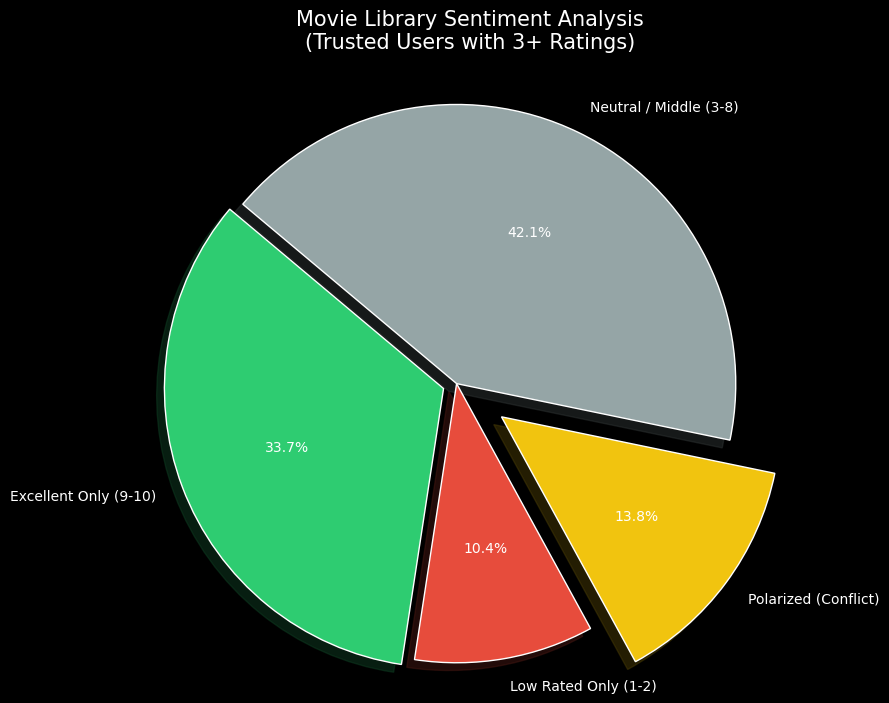

In [46]:
# --- 1. Prepare Exclusive Data for the Pie ---
# We use the sets of IDs calculated in the previous trusted analysis step

# Category A: Trusted Polarized (The "Love/Hate" movies)
polarized_count = len(trusted_polarized_ids)

# Category B: Trusted Excellent ONLY (9-10 scores, but NO 1-2 scores)
# We subtract the polarized ones to avoid double counting
excellent_only_count = len(trusted_excellent_movie_ids - trusted_low_movie_ids)

# Category C: Trusted Low-Rated ONLY (1-2 scores, but NO 9-10 scores)
low_only_count = len(trusted_low_movie_ids - trusted_excellent_movie_ids)

# Category D: Neutral / Middle (Movies that never received a 1, 2, 9, or 10)
# These are movies where all trusted users gave scores between 3 and 8
all_trusted_movie_ids = set(trusted_df['MOVIE_ID'].unique())
neutral_count = len(all_trusted_movie_ids - (trusted_excellent_movie_ids | trusted_low_movie_ids))

# --- 2. Setup the Plot ---
labels = [
    'Excellent Only (9-10)',
    'Low Rated Only (1-2)',
    'Polarized (Conflict)',
    'Neutral / Middle (3-8)'
]

sizes = [excellent_only_count, low_only_count, polarized_count, neutral_count]
colors = ['#2ecc71', '#e74c3c', '#f1c40f', '#95a5a6'] # Green, Red, Gold, Gray
explode = (0.05, 0, 0.2, 0) # Explode Excellent and Polarized to highlight them

# --- 3. Create the Visualization ---
plt.figure(figsize=(10, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.title('Movie Library Sentiment Analysis\n(Trusted Users with 3+ Ratings)', fontsize=15, pad=20)
plt.axis('equal') # Ensures pie is a circle

# --- 4. Save and Print Results ---
pie_path = os.path.join(PLOTS_DIR, 'trusted_movie_sentiment_pie.png')
plt.savefig(pie_path, bbox_inches='tight')

print(f"{GREEN}Trusted Quality Pie Chart saved to: {pie_path}{RESET_COLORS}")
print(f"\n{YELLOW}--- Numerical Breakdown (Trusted Only) ---{RESET_COLORS}")
print(f"Total Unique Movies Rated: {len(all_trusted_movie_ids)}")
print(f"Excellent Only:            {excellent_only_count}")
print(f"Low Rated Only:            {low_only_count}")
print(f"Polarized (Both):          {polarized_count}")
print(f"Neutral / Middle:          {neutral_count}")

## Normalization


### 2) Mean centering normalize RATINGs because some users are "easy graders" (average 9/10) and some are "harsh critics" (average 4/10). We want to know if a user liked a movie **more than their own average**

In [47]:
# 1. Calculate the average RATING for each user
User_Mean = split_data.groupby('USER_ID')['RATING'].mean()

# 2. Map those means back to the main dataframe
split_data['User_Mean'] = split_data['USER_ID'].map(User_Mean)

# 3. Create the Normalized RATING (Relative Preference)
split_data['RATING_Norm'] = split_data['RATING'] - split_data['User_Mean']

print("✅ Normalization complete.")
print(split_data[['USER_ID', 'RATING', 'User_Mean', 'RATING_Norm']].head())

✅ Normalization complete.
   USER_ID  RATING  User_Mean  RATING_Norm
0  4592644      10  10.000000     0.000000
1  3174947       3   7.355556    -4.355556
2  3780035       8   7.875000     0.125000
3  4592628       1   1.000000     0.000000
4  3174947       8   7.355556     0.644444


#### "Easy vs. Harsh" grader

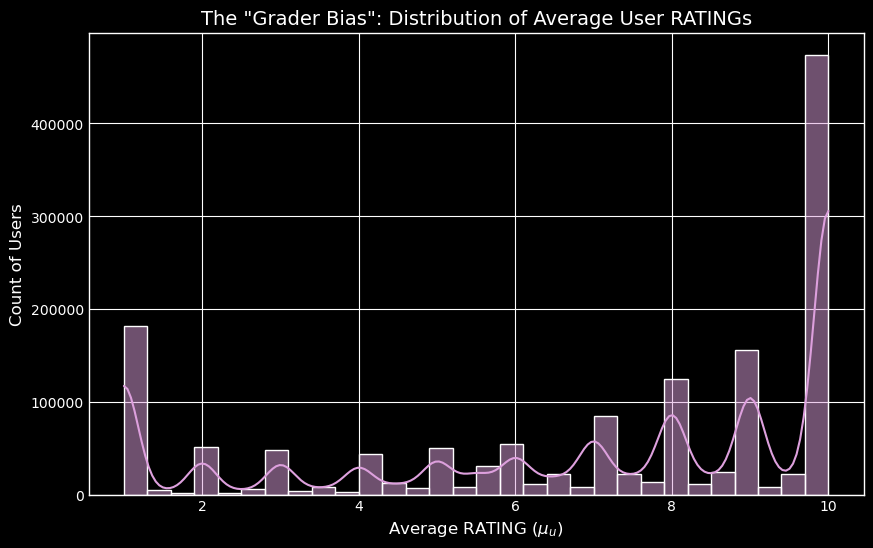

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(User_Mean, bins=30, color='plum', kde=True)

plt.title('The "Grader Bias": Distribution of Average User RATINGs', fontsize=14)
plt.xlabel('Average RATING ($\mu_u$)', fontsize=12)
plt.ylabel('Count of Users', fontsize=12)

plt.savefig('plots/user_bias_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

#### Density of predictions to the user's baseline (for a sample up to 5000)

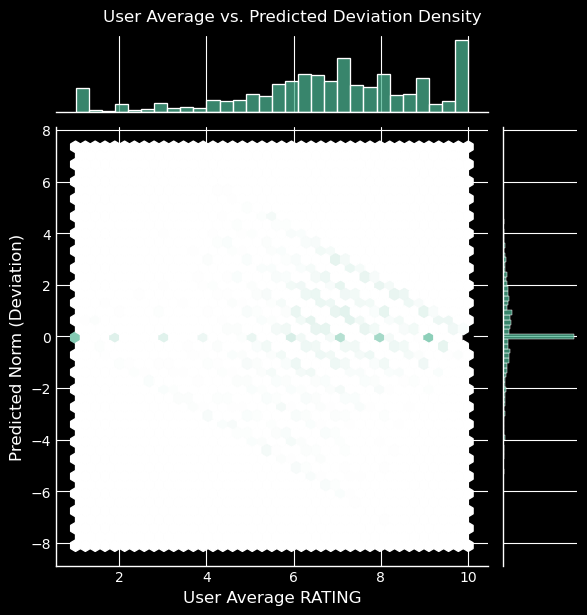

In [49]:
# Using a sample of 5000 points so the plot stays fast and readable
g = sns.jointplot(
    data=split_data.sample(min(5000, len(split_data))),
    x='User_Mean',         # Fixed name from user_means to User_Mean
    y='RATING_Norm',
    kind="hex",
    color="#4CB391"
)

g.fig.suptitle('User Average vs. Predicted Deviation Density', y=1.02)
g.set_axis_labels('User Average RATING', 'Predicted Norm (Deviation)')

plt.savefig('plots/prediction_joint_hex.png', dpi=300, bbox_inches='tight')
plt.show()

#### Feature Relationships (**Correlation**)

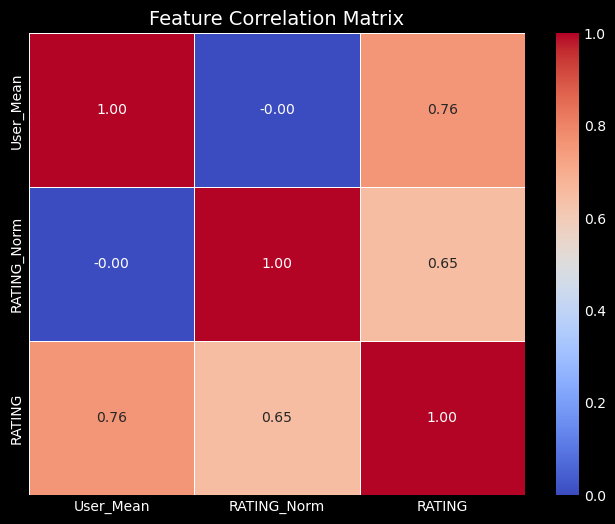

In [50]:
# Select only the numerical columns for correlation
corr_data = split_data[['User_Mean', 'RATING_Norm', 'RATING']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Matrix', fontsize=14)
plt.savefig('plots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

#### Mean Predicted Norm: Top 10 Movies

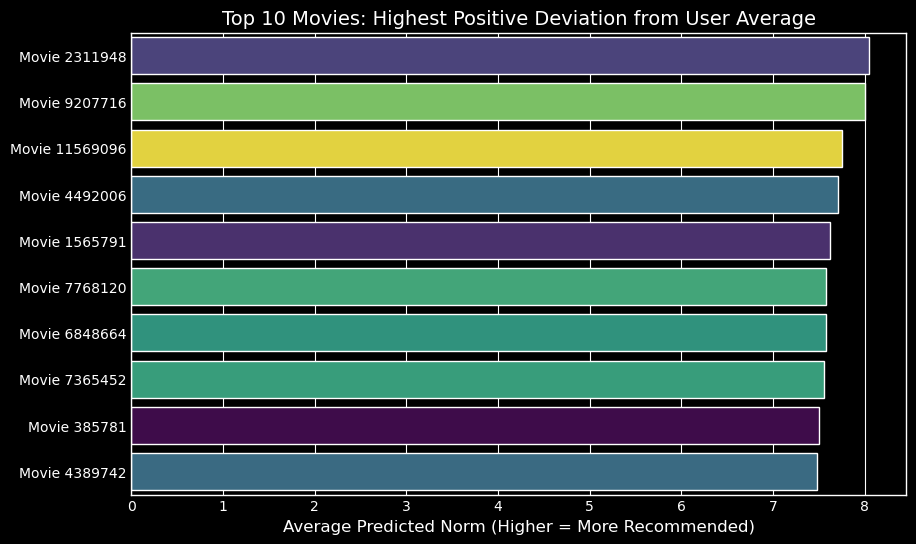

In [51]:
# Group by MOVIE_ID and find the average predicted norm
top_movies = split_data.groupby('MOVIE_ID')['RATING_Norm'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
# Fixed: Removed int(i) as IMDB IDs are strings
sns.barplot(
    x=top_movies.values,
    y=[f"Movie {i}" for i in top_movies.index],
    hue=top_movies.index,
    palette='viridis',
    legend=False
)

plt.title('Top 10 Movies: Highest Positive Deviation from User Average', fontsize=14)
plt.xlabel('Average Predicted Norm (Higher = More Recommended)')
plt.savefig('plots/top_10_recommendations.png', dpi=300, bbox_inches='tight')
plt.show()

#### TODO:: NA TO KSANADW GT TO KAINOURIO CSV THA EXEI POLLA LIGOTERA 3) Filter out user with 1 or 2 RATINGs. We dont need them and are noise

In [52]:
# Count RATINGs per user
user_counts = split_data.groupby('USER_ID').size()

# Keep only users with 5 or more RATINGs
active_USER_IDs = user_counts[user_counts >= 5].index
split_data_filtered = split_data[split_data['USER_ID'].isin(active_USER_IDs)].copy()

print(f"Original users: {len(user_counts):,}")
print(f"Active users (5+ RATINGs): {len(active_USER_IDs):,}")
print(f"Data remaining: {len(split_data_filtered):,} rows.")

Original users: 1,499,238
Active users (5+ RATINGs): 120,250
Data remaining: 2,822,422 rows.


### Now the code is able to predict the RATING_Norm. So the results mean either: 2.5 > **User will likely love current movie** or if < -3.0 **User will likely hate the movie**

### Build **User - Item Matrix**

In [53]:
# Initialize the encoders
user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

# Fit and transform the IDs into integer indices
split_data_filtered['USER_IDx'] = user_encoder.fit_transform(split_data_filtered['USER_ID'])
split_data_filtered['MOVIE_IDx'] = movie_encoder.fit_transform(split_data_filtered['MOVIE_ID'])

# Let's see the result
n_users = split_data_filtered['USER_IDx'].nunique()
n_movies = split_data_filtered['MOVIE_IDx'].nunique()

print(f"✅ Label Encoding Complete.")
print(f"Total Unique Users: {n_users:,}")
print(f"Total Unique Movies: {n_movies:,}")
print(split_data_filtered[['USER_ID', 'USER_IDx', 'MOVIE_ID', 'MOVIE_IDx']].head())

✅ Label Encoding Complete.
Total Unique Users: 120,250
Total Unique Movies: 296,050
   USER_ID  USER_IDx  MOVIE_ID  MOVIE_IDx
1  3174947     26957    118688      56791
2  3780035     29139    387887     102045
4  3174947     26957     94721      45010
5  1162550     14030    114891      55016
8  3174947     26957    120601      57899


#### Distribution & Threshold Analysis

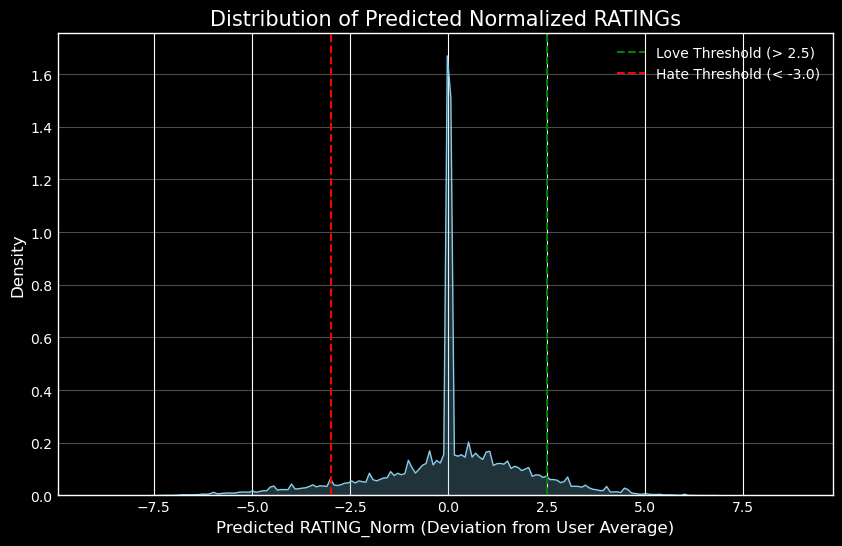

In [54]:
plt.figure(figsize=(10, 6))

# Plotting the density of predictions
sns.kdeplot(split_data['RATING_Norm'], fill=True, color="skyblue", bw_adjust=0.5)

plt.axvline(2.5, color='green', linestyle='--', label='Love Threshold (> 2.5)')
plt.axvline(-3.0, color='red', linestyle='--', label='Hate Threshold (< -3.0)')

# Formatting
plt.title('Distribution of Predicted Normalized RATINGs', fontsize=15)
plt.xlabel('Predicted RATING_Norm (Deviation from User Average)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.savefig('plots/distribution_&_threshold.png', dpi=300, bbox_inches='tight')

plt.show()

#### Spread of normalized RATING. It will show if "Love" predictions are extreme outliers or not

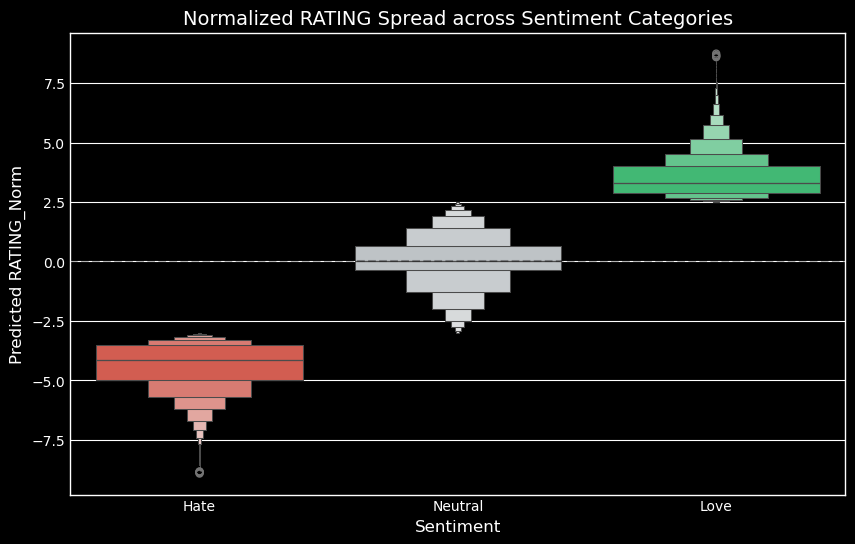

In [55]:
# 1. Create the Sentiment column first
def get_sentiment(x):
    if x > 2.5:
        return 'Love'
    elif x < -3.0:
        return 'Hate'
    else:
        return 'Neutral'

# Apply the function to create the missing column
split_data['Sentiment'] = split_data['RATING_Norm'].apply(get_sentiment)

# 2. Ensure the save directory exists
if not os.path.exists('plots'):
    os.makedirs('plots')

# 3. Now run your plotting code
plt.figure(figsize=(10, 6))

sns.boxenplot(
    data=split_data,
    x='Sentiment',
    y='RATING_Norm',
    hue='Sentiment',
    palette={'Love':'#2ecc71', 'Neutral':'#bdc3c7', 'Hate':'#e74c3c'},
    order=['Hate', 'Neutral', 'Love'],
    legend=False
)

plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title('Normalized RATING Spread across Sentiment Categories', fontsize=14)
plt.ylabel('Predicted RATING_Norm')
plt.savefig('plots/sentiment_boxen_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

#### Classification Count (The "Sentiment" Bar)

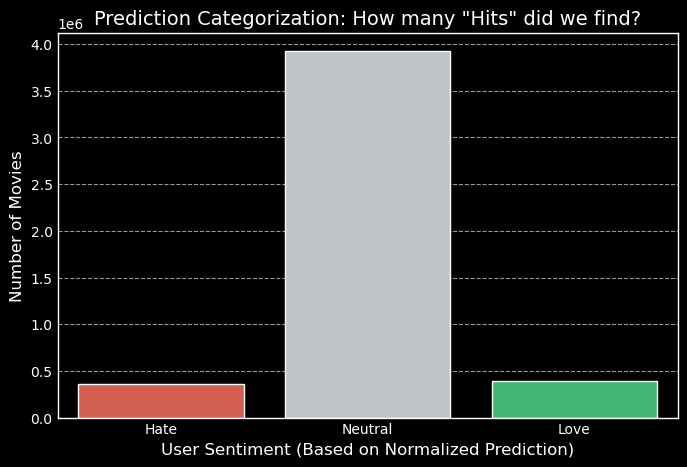

In [56]:
# Create a helper column for sentiment based on your thresholds
def get_sentiment(x):
    if x > 2.5: return 'Love'
    elif x < -3.0: return 'Hate'
    else: return 'Neutral'

# Applying the logic to your dataframe
split_data['Sentiment'] = split_data['RATING_Norm'].apply(get_sentiment)

# Plotting with the updated Seaborn syntax
plt.figure(figsize=(8, 5))
sns.countplot(
    data=split_data,
    x='Sentiment',
    hue='Sentiment',
    palette={'Love':'#2ecc71', 'Neutral':'#bdc3c7', 'Hate':'#e74c3c'},
    order=['Hate', 'Neutral', 'Love'],
    legend=False              # Removes the redundant legend
)

plt.title('Prediction Categorization: How many "Hits" did we find?', fontsize=14)
plt.xlabel('User Sentiment (Based on Normalized Prediction)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.savefig('plots/RATING_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

#### Because the data are too big, the **User - Item Matrix** will be compressed. This way K-means won't struggle

In [57]:
# Create the matrix: (data, (row_indices, col_indices))
user_movie_sparse = csr_matrix(
    (split_data_filtered['RATING_Norm'], (split_data_filtered['USER_IDx'], split_data_filtered['MOVIE_IDx'])),
    shape=(n_users, n_movies)
)

print(f"✅ Sparse Matrix created with shape: {user_movie_sparse.shape}")

✅ Sparse Matrix created with shape: (120250, 296050)


In [ ]:
print(split_data.columns)

## Calculate "trusted" graders dispersity (Trusted graders are those who have put grades to more than 2 movie)

### Step 1) Calculate Mean RATINGs per User only for those with **greater than 2 movies rated**

In [58]:
# Calculate number of RATINGs per user
user_counts = split_data.groupby('USER_ID')['RATING'].count()

# Calculate statistics
mean_ratings = user_counts.mean()
median_ratings = user_counts.median()

print(f"Mean RATINGs per user: {mean_ratings:.2f}")
print(f"Median RATINGs per user: {median_ratings:.2f}")

Mean RATINGs per user: 3.11
Median RATINGs per user: 1.00


In [ ]:
def plot_trusted_users_analysis():
    # 1. Identify 'Trusting' Users
    user_counts = split_data.groupby('USER_ID')['RATING'].count()
    trusted_ids = user_counts[user_counts >= MIn_ratings_THRESHOLD].index
    trusted_split_data = split_data[split_data['USER_ID'].isin(trusted_ids)]

    # Calculate the mean RATING per trusting user
    trusted_user_means = trusted_split_data.groupby('USER_ID')['RATING'].mean()

    # 2. Setup Comparison Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # TOP: Raw RATING Dispersion (The "Noise")
    sns.boxplot(
        x=trusted_split_data['RATING'],
        ax=ax1,
        color='skyblue',
        whiskerprops={'color': 'red', 'linewidth': 2},
        capprops={'color': 'red'},
        flierprops={"marker": "x", "markeredgecolor": "black", "alpha": 0.2}
    )
    ax1.set_title(f'Raw RATINGs Dispersion (Users with ≥ {MIn_ratings_THRESHOLD} RATINGs)', fontsize=14)

    # BOTTOM: Mean RATING Dispersion (The "Signal")
    sns.boxplot(
        x=trusted_user_means,
        ax=ax2,
        color='gold',
        whiskerprops={'color': 'red', 'linewidth': 2},
        capprops={'color': 'red'},
        flierprops={"marker": "o", "markeredgecolor": "darkorange", "markersize": 4}
    )
    ax2.set_title('Trusting Users: Dispersion of Individual Average RATINGs', fontsize=14)

    plt.xlabel('RATING Value', fontsize=12)
    plt.tight_layout()

    # 3. Save
    plt.savefig(TRUSTED_USERS_PLOT)
    plt.show()

    # Statistics for your notes
    print(f"Total Trusted Users: {len(trusted_ids)}")
    print(f"Average RATING of Trusted Users: {trusted_user_means.mean():.2f}")

plot_trusted_users_analysis()

### Step 2) "Trusted Graders" vs all graders

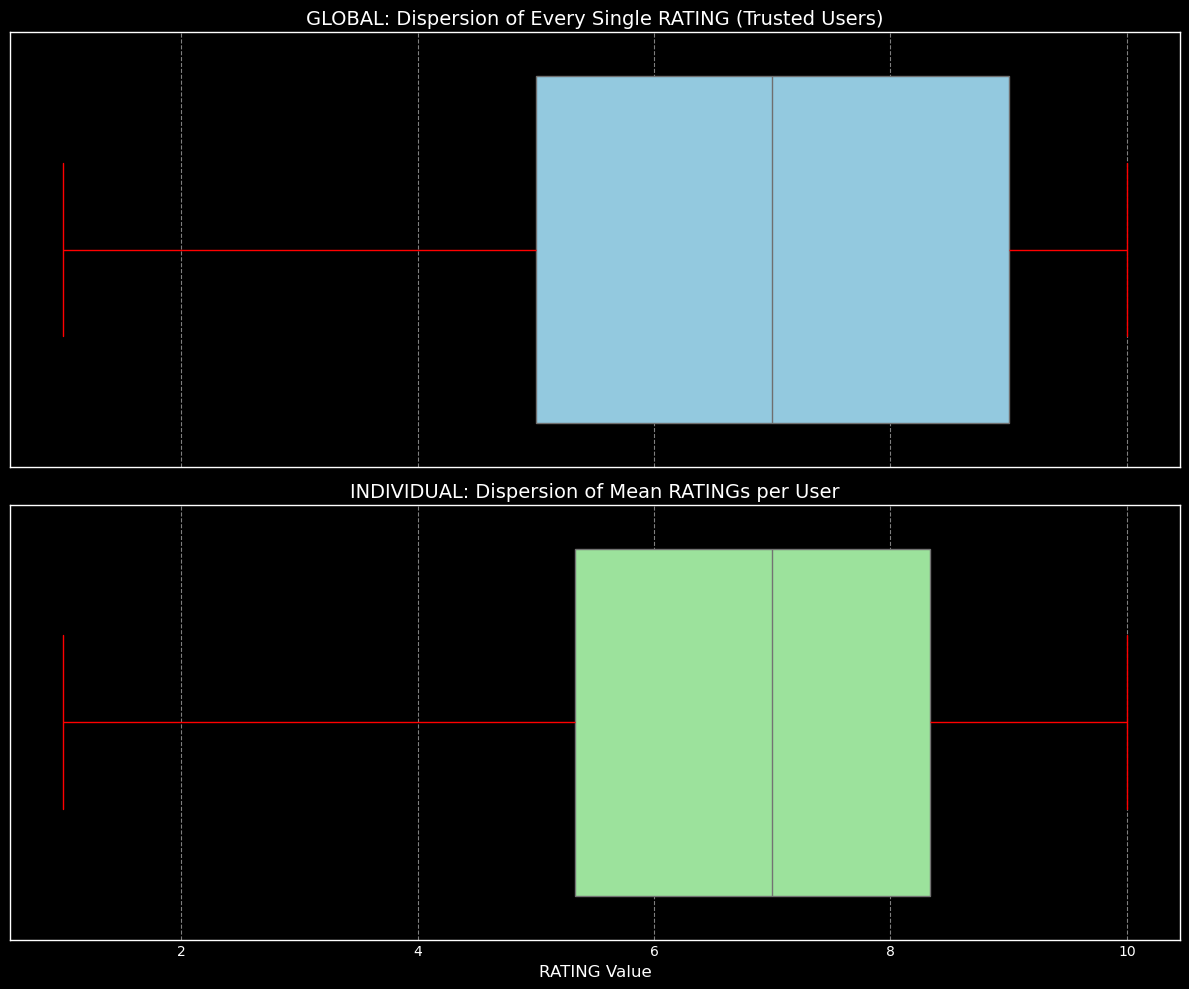

Comparison plot saved to: ../plots/global_vs_trusted_comparison.png


In [59]:
def plot_global_vs_trusted_comparison():
    # 1. Prepare Data
    # Calculate counts to filter 'trusted' users (>= 3 movies)
    user_counts = split_data.groupby('USER_ID')['RATING'].count()
    active_USER_IDs = user_counts[user_counts >= 3].index
    filtered_split_data = split_data[split_data['USER_ID'].isin(active_USER_IDs)]

    # Calculate the mean RATING for EVERY trusted individual user
    user_means = filtered_split_data.groupby('USER_ID')['RATING'].mean()

    # 2. Setup Figure with 2 Subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # --- TOP PLOT: All RATINGs (The Raw Dispersion) ---
    sns.boxplot(
        x=filtered_split_data['RATING'],
        ax=ax1,
        color='skyblue',
        whiskerprops={'color': 'red', 'linestyle': '-'},
        capprops={'color': 'red'},
        flierprops={"marker": "x", "markeredgecolor": "black", "markersize": 5, "alpha": 0.3}
    )
    ax1.set_title('GLOBAL: Dispersion of Every Single RATING (Trusted Users)', fontsize=14)
    ax1.grid(axis='x', linestyle='--', alpha=0.5)

    # --- BOTTOM PLOT: User Means (The "Trusted" Average Dispersion) ---
    sns.boxplot(
        x=user_means,
        ax=ax2,
        color='lightgreen',
        whiskerprops={'color': 'red'},
        capprops={'color': 'red'},
        flierprops={"marker": "o", "markeredgecolor": "darkgreen", "markersize": 4}
    )
    ax2.set_title('INDIVIDUAL: Dispersion of Mean RATINGs per User', fontsize=14)
    ax2.grid(axis='x', linestyle='--', alpha=0.5)

    # Final Formatting
    plt.xlabel('RATING Value', fontsize=12)
    plt.tight_layout()

    # 3. Save to PLOTS_DIR
    comparison_path = os.path.join(PLOTS_DIR, 'global_vs_trusted_comparison.png')
    plt.savefig(comparison_path)
    plt.show()

    print(f"Comparison plot saved to: {comparison_path}")

# Run the comparison
plot_global_vs_trusted_comparison()